### **Training the Stock Prediction Model**

In [ ]:
# Importing libraries
import pandas as pd
import numpy as np

# Importing dataset (use the correct path to your Google Drive)
nv_complete_data = pd.read_csv("/content/drive/MyDrive/AIC2024/CoLab Files/2024Training - STOCK_US_XNAS_NVDA (1).csv")

# Printing dataset header
print(nv_complete_data.head())


         Date    Open    High     Low   Close       Volume
0  12/31/2024  138.03  138.07  133.83  134.29  155,659,203
1  12/30/2024  134.83  140.27  134.02  137.49  167,734,703
2  12/27/2024  138.55  139.02  134.71  137.01  170,582,594
3  12/26/2024  139.70  140.85  137.73  139.93  116,519,102
4  12/24/2024  140.00  141.90  138.65  140.22  105,157,000


In [ ]:
# Filtering Open column
nv_training_processed = nv_complete_data[['Open']].values

# Scaling features
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))
nv_training_scaled = scaler.fit_transform(nv_training_processed)

len(nv_training_scaled)  # 1257


252

In [ ]:
# Training features contain data of the last 60 days
# Training labels contain data of the 61st day
nv_training_features = []
nv_training_labels = []

for i in range(60, len(nv_training_scaled)):
    nv_training_features.append(nv_training_scaled[i-60:i, 0])
    nv_training_labels.append(nv_training_scaled[i, 0])


In [ ]:
import numpy as np

# Converting training data to numpy arrays
X_train = np.array(nv_training_features)
y_train = np.array(nv_training_labels)

# Print the shape of our dataset
print(X_train.shape)
print(y_train.shape)
# (1197, 60)
# (1197,)

# Converting data into 3D shape
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))


(192, 60)
(192,)


In [ ]:
# Importing libraries
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Activation, Dense, Flatten, Dropout, LSTM
from tensorflow.keras.models import Model

# Defining the LSTM network
input_layer = Input(shape=(X_train.shape[1], 1))
lstm1 = LSTM(100, activation='relu', return_sequences=True)(input_layer)
do1 = Dropout(0.2)(lstm1)
lstm2 = LSTM(100, activation='relu', return_sequences=True)(do1)
do2 = Dropout(0.2)(lstm2)
lstm3 = LSTM(100, activation='relu', return_sequences=True)(do2)
do3 = Dropout(0.2)(lstm3)
lstm4 = LSTM(100, activation='relu')(do3)
do4 = Dropout(0.2)(lstm4)
output_layer = Dense(1)(do4)

# Creating the model
model = Model(input_layer, output_layer)
model.compile(optimizer='adam', loss='mse')


In [ ]:
# Convert the output y into a column vector
print(X_train.shape)
print(y_train.shape)

y_train = y_train.reshape(-1, 1)

print(y_train.shape)
# (1197, 60, 1)
# (1197,)
# (1197, 1)

# Training the model
model_history = model.fit(X_train, y_train, epochs=100, verbose=1, batch_size=32)


(192, 60, 1)
(192,)
(192, 1)
Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 168ms/step - loss: 0.2506
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 195ms/step - loss: 0.0518
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 282ms/step - loss: 0.0444
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 215ms/step - loss: 0.0317
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 170ms/step - loss: 0.0301
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 238ms/step - loss: 0.0250
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 174ms/step - loss: 0.0218
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 167ms/step - loss: 0.0205
Epoch 9/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 167ms/step - loss: 0.0175
Epoch 10/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 168ms/step - loss: 0.0171
Epoch 11/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 170ms/step - loss: 0.0157
Epoch 12/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 167ms/step - loss: 0.0150
Epoch 13/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 273ms/step - loss: 0.0161
Epoch 14/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 316ms/step - loss: 0.0141
Epoch 15/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 1

### **Testing the Stock Prediction Model**

In [ ]:
import pandas as pd

# Creating test set (use your correct file path!)
nv_testing_complete_data = pd.read_csv("/content/drive/MyDrive/AIC2024/CoLab Files/2025Test - STOCK_US_XNAS_NVDA (1).csv")

# Selecting only the 'Open' column
nv_testing_processed = nv_testing_complete_data[['Open']].values

# Concatenating training and test sets
# This helps predict the first value in the test set using the past 60 days of data
nv_all_data = pd.concat((nv_complete_data['Open'], nv_testing_complete_data['Open']), axis=0)

# Creating the final input feature set
test_inputs = nv_all_data[len(nv_all_data) - len(nv_testing_complete_data) - 60:].values

print(test_inputs.shape)
# (80,)


(93,)


In [ ]:
# Reshaping test inputs into a column vector
test_inputs = test_inputs.reshape(-1, 1)

# Scaling the test inputs using the same scaler as the training data
test_inputs = scaler.transform(test_inputs)

# Printing the shape of test inputs
print(test_inputs.shape)
# (80, 1)

# Creating the test features (similar to training data)
fb_test_features = []
for i in range(60, 80):
    fb_test_features.append(test_inputs[i-60:i, 0])


(93, 1)


In [ ]:
# Converting the test feature set into a NumPy array
X_test = np.array(fb_test_features)

# Printing the shape of the test feature set
print(X_test.shape)
# (20, 60)

# Converting test data into 3D shape for LSTM input
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# Printing the reshaped test set
print(X_test.shape)
# (20, 60, 1)


(20, 60)
(20, 60, 1)


In [ ]:
# Making predictions on the test set
y_pred = model.predict(X_test)

# Printing the shape of predicted output
print(y_pred.shape)

# Converting scaled data back to original values
y_pred = scaler.inverse_transform(y_pred)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 650ms/step
(20, 1)


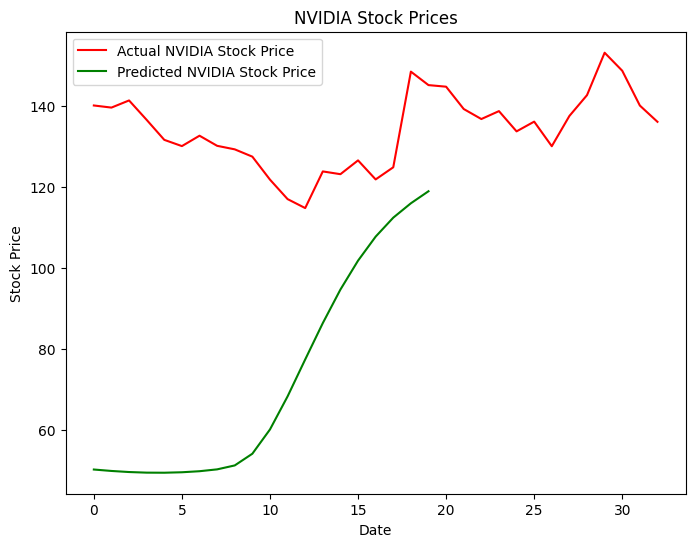

In [ ]:
# Plotting original and predicted stock values
plt.figure(figsize=(8,6))
plt.plot(nv_testing_processed, color='red', label='Actual NVIDIA Stock Price')
plt.plot(y_pred, color='green', label='Predicted NVIDIA Stock Price')
plt.title('NVIDIA Stock Prices')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.legend()
plt.show()


 ---
 --- ---
 ---
  ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 ---
  ---
 --- ---
 ---
  ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 --- ---
 ---